<a href="https://colab.research.google.com/github/SamikshKodgire/AAI540_Group-4_E-Commerce_Risk_Management_Solutions/blob/main/AAI_540_Group4_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Setup and Folder Structure

To keep the project organised and reproducible, I first created a structured folder hierarchy for storing raw datasets, processed data, notebooks, source code, models, and pipeline-related files. This structure will help maintain a clean workflow throughout the project and make it easier to integrate MLOps components later.

In [ ]:
import os

folders = [
    "project/data/raw",
    "project/data/interim",
    "project/data/processed",
    "project/notebooks",
    "project/src/data",
    "project/src/features",
    "project/src/training",
    "project/models",
    "project/pipelines",
    "project/tests"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [ ]:
os.listdir("project")

['tests', 'src', 'data', 'models', 'pipelines', 'notebooks']

# Uploading and Organising the Raw Dataset

In this step, I uploaded the required Olist ecommerce dataset files into the Colab environment and moved them into the raw data directory. Keeping the original datasets untouched is important because it preserves data integrity and allows reproducible preprocessing workflows later in the project.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv


In [ ]:
import shutil

csv_files = [
    "olist_orders_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_products_dataset.csv",
    "product_category_name_translation.csv"
]

for file in csv_files:
    shutil.move(file, f"project/data/raw/{file}")

print("Files moved successfully.")

Files moved successfully.


In [ ]:
os.listdir("project/data/raw")

['olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'product_category_name_translation.csv',
 'olist_order_reviews_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_products_dataset.csv']

# Loading the Required Datasets

The Olist dataset consists of multiple relational tables representing different parts of the ecommerce workflow such as orders, reviews, products, payments, and order items.

I loaded the required datasets into Pandas DataFrames to begin preprocessing, feature engineering, and dataset integration for the machine learning pipeline.

In [ ]:
import pandas as pd

orders = pd.read_csv(
    "project/data/raw/olist_orders_dataset.csv"
)

reviews = pd.read_csv(
    "project/data/raw/olist_order_reviews_dataset.csv"
)

items = pd.read_csv(
    "project/data/raw/olist_order_items_dataset.csv"
)

payments = pd.read_csv(
    "project/data/raw/olist_order_payments_dataset.csv"
)

products = pd.read_csv(
    "project/data/raw/olist_products_dataset.csv"
)

translations = pd.read_csv(
    "project/data/raw/product_category_name_translation.csv"
)

# Translating Product Categories to English

The original product category names in the dataset are stored in Portuguese. To improve readability and make downstream analysis easier, I merged the product category translation dataset with the products table to obtain English category names.

In [ ]:
## Merge Product Translation

products = products.merge(
    translations,
    on='product_category_name',
    how='left'
)

# Converting Date Columns into Datetime Format

Several columns in the orders dataset contain timestamp information related to purchases and deliveries. I converted these columns into datetime format so that time-based calculations such as delivery delays could be performed accurately.

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)

# Creating the Delivery Delay Feature

Delivery performance is an important factor in customer satisfaction. In this step, I created a new feature called `delivery_delay_days`, which measures the difference between the estimated delivery date and the actual delivery date.

Positive values indicate delayed deliveries, while negative values indicate early deliveries.

In [ ]:
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.days

# Creating the Base Dataset

The orders dataset serves as the primary entity table for this project, where each row represents a single ecommerce order. I created a copy of this dataset to act as the foundation for all subsequent merging and feature engineering operations.

In [ ]:
df = orders.copy()

# Merging Customer Review Information

Customer review scores provide direct insight into customer satisfaction and purchasing experience. In this step, I merged review scores into the main dataset using the order identifier so that review-related features could contribute to the prediction task.

In [ ]:
df = df.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

# Creating the High-Risk Target Variable

To transform the problem into a binary classification task, I engineered a target variable called `high_risk`.

An order is classified as high-risk if it satisfies one or more of the following conditions:

- Review score less than or equal to 2
- Order status marked as cancelled or unavailable
- Delivery delay greater than 7 days

This business-driven logic helps identify transactions that are likely associated with customer dissatisfaction or operational issues.

In [ ]:
import numpy as np

df['high_risk'] = np.where(
    (
        (df['review_score'] <= 2)
        |
        (df['order_status'].isin([
            'canceled',
            'unavailable'
        ]))
        |
        (df['delivery_delay_days'] > 7)
    ),
    1,
    0
)

# Aggregating Payment Features

Some orders contain multiple payment records. To maintain one row per order in the final machine learning dataset, I aggregated payment-related information at the order level.

Features such as total payment value and maximum number of payment instalments were extracted for each order.

In [ ]:
payment_features = payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max'
}).reset_index()

# Aggregating Order Item Features

Orders may contain multiple purchased items. In this step, I aggregated item-level information into order-level features such as:

- Total product price
- Total freight value
- Number of purchased items

These features help capture purchasing behaviour and transaction complexity.

In [ ]:
item_features = items.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum',
    'order_item_id': 'count'
}).reset_index()

In [ ]:
item_features.rename(columns={
    'order_item_id': 'item_count'
}, inplace=True)

# Merging Engineered Features into the Main Dataset

After creating the aggregated payment and order item features, I merged them into the main dataset using the order identifier. This resulted in a more comprehensive dataset containing operational, financial, and behavioural features for each order.

In [ ]:
df = df.merge(
    payment_features,
    on='order_id',
    how='left'
)

df = df.merge(
    item_features,
    on='order_id',
    how='left'
)

# Adding Product Category Information

Product category information was added to capture product-level purchasing patterns and risk behaviour. Since a single order may contain multiple products, I selected the first available product category associated with each order as a representative feature.

In [ ]:
item_products = items.merge(
    products[
        [
            'product_id',
            'product_category_name_english'
        ]
    ],
    on='product_id',
    how='left'
)

In [ ]:
category_features = item_products.groupby(
    'order_id'
)['product_category_name_english'].first().reset_index()

In [ ]:
df = df.merge(
    category_features,
    on='order_id',
    how='left'
)

# Selecting the Final Feature Set

To keep the initial machine learning pipeline manageable and interpretable, I selected a subset of the most relevant features for the baseline model.

The selected features include payment behaviour, freight cost, delivery performance, item count, review information, and product category data.

In [ ]:
final_columns = [
    'payment_value',
    'payment_installments',
    'price',
    'freight_value',
    'item_count',
    'delivery_delay_days',
    'review_score',
    'product_category_name_english',
    'high_risk'
]

In [ ]:
final_df = df[final_columns]

# Handling Missing Values and Duplicate Records

Before finalising the dataset, I handled missing values and removed duplicate records to improve overall dataset quality and ensure compatibility with downstream machine learning models.

In [ ]:
final_df = final_df.fillna(0)

In [ ]:
final_df = final_df.drop_duplicates()

In [ ]:
# Finalizng teh final shape of merged dataset

final_df.shape

(97716, 9)

In [ ]:
final_df.head()

,payment_value,payment_installments,price,freight_value,item_count,delivery_delay_days,review_score,product_category_name_english,high_risk
0,38.71,1.0,29.99,8.72,1.0,-8.0,4.0,housewares,0
1,141.46,1.0,118.70,22.76,1.0,-6.0,4.0,perfumery,0
2,179.12,3.0,159.90,19.22,1.0,-18.0,5.0,auto,0
3,72.20,1.0,45.00,27.20,1.0,-13.0,5.0,pet_shop,0
4,28.62,1.0,19.90,8.72,1.0,-10.0,5.0,stationery,0


# Analysing the Class Distribution

Understanding the distribution of the target variable is important before training machine learning models. In this step, I analysed the proportion of high-risk and low-risk transactions to determine whether the dataset is balanced or imbalanced.

In [ ]:
final_df['high_risk'].value_counts(normalize=True)

,proportion
high_risk,
0,0.842871
1,0.157129


# Conclusion: Class Imbalance Analysis

The target variable distribution shows that approximately 84% of the transactions belong to the low-risk class, while around 16% belong to the high-risk class.

Although the dataset is moderately imbalanced, this reflects a realistic ecommerce business scenario where problematic transactions occur less frequently than successful ones. The imbalance is not severe enough to prevent effective model training, especially when using ensemble-based algorithms such as Random Forest or XGBoost.

Because of this imbalance, I will focus more on evaluation metrics such as Recall, F1-Score, Precision, and ROC-AUC rather than relying only on accuracy. Recall will be especially important because failing to identify genuinely high-risk transactions could lead to customer dissatisfaction, operational losses, and return-related costs.

At this stage, I will preserve the original class distribution to establish a realistic baseline model before experimenting with balancing techniques such as class weighting or SMOTE in later stages of the project.

# Saving the Final Machine Learning Dataset

After completing preprocessing, feature engineering, dataset merging, and validation, I saved the final processed dataset for use in the modelling phase of the project.

This final dataset will serve as the foundation for exploratory data analysis, machine learning model training, experiment tracking, deployment, and monitoring workflows later in the project.

In [ ]:
final_df.to_csv(
    "project/data/processed/final_ml_dataset.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download(
    "project/data/processed/final_ml_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# --------  Exploratory Data Analysis --------

In [1]:
import pandas as pd

final_df = pd.read_csv(
    "final_ml_dataset.csv"
)


Before developing machine learning models, we will explore the dataset to better understand feature distributions, identify potential relationships with the target variable, and uncover patterns that may influence high-risk ecommerce transactions.

The goal of this analysis is to gain business insights, validate engineered features, and identify variables that may contribute most strongly to customer dissatisfaction and operational risk.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print(final_df.shape)
final_df.head()

(97716, 9)


,payment_value,payment_installments,price,freight_value,item_count,delivery_delay_days,review_score,product_category_name_english,high_risk
0,38.71,1.0,29.99,8.72,1.0,-8.0,4.0,housewares,0
1,141.46,1.0,118.70,22.76,1.0,-6.0,4.0,perfumery,0
2,179.12,3.0,159.90,19.22,1.0,-18.0,5.0,auto,0
3,72.20,1.0,45.00,27.20,1.0,-13.0,5.0,pet_shop,0
4,28.62,1.0,19.90,8.72,1.0,-10.0,5.0,stationery,0


# Dataset Overview

We begin by examining the overall structure of the dataset, including feature types, missing values, and summary statistics. This provides a high-level understanding of the data before deeper analysis.

In [3]:
final_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97716 entries, 0 to 97715
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   payment_value                  97716 non-null  float64
 1   payment_installments           97716 non-null  float64
 2   price                          97716 non-null  float64
 3   freight_value                  97716 non-null  float64
 4   item_count                     97716 non-null  float64
 5   delivery_delay_days            97716 non-null  float64
 6   review_score                   97716 non-null  float64
 7   product_category_name_english  97716 non-null  object 
 8   high_risk                      97716 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 6.7+ MB


In [4]:
final_df.describe()

,payment_value,payment_installments,price,freight_value,item_count,delivery_delay_days,review_score,high_risk
count,97716.000000,97716.000000,97716.000000,97716.000000,97716.000000,97716.000000,97716.000000,97716.000000
mean,162.458589,2.958492,137.999734,22.825170,1.135843,-11.521900,4.042654,0.157129
std,223.168154,2.728154,211.550947,21.796069,0.550391,10.300799,1.394216,0.363924
min,0.000000,0.000000,0.000000,0.000000,0.000000,-147.000000,0.000000,0.000000
25%,62.547500,1.000000,45.800000,13.840000,1.000000,-17.000000,4.000000,0.000000
50%,106.440000,2.000000,87.000000,17.210000,1.000000,-12.000000,5.000000,0.000000
75%,178.470000,4.000000,149.990000,24.210000,1.000000,-7.000000,5.000000,0.000000
max,13664.080000,24.000000,13440.000000,1794.960000,21.000000,188.000000,5.000000,1.000000


In [12]:
final_df.columns.tolist()

['payment_value',
 'payment_installments',
 'price',
 'freight_value',
 'item_count',
 'delivery_delay_days',
 'review_score',
 'product_category_name_english',
 'high_risk']

# Distribution of High-Risk Transactions

Understanding the target variable distribution is important because it reveals the proportion of high-risk and low-risk transactions present in the dataset.

This analysis helps assess class balance and provides context for selecting appropriate evaluation metrics during model development.

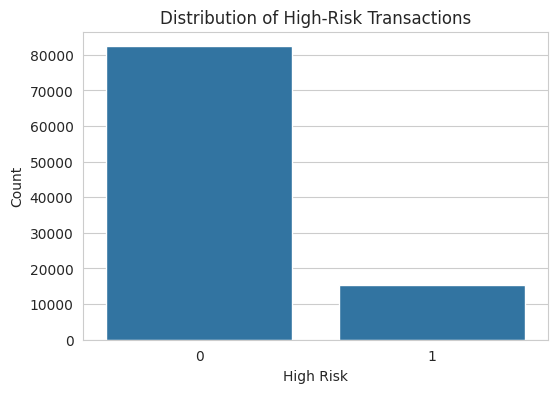

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='high_risk',
    data=final_df
)

plt.title('Distribution of High-Risk Transactions')
plt.xlabel('High Risk')
plt.ylabel('Count')

plt.show()

### Observation

The dataset contains a substantially larger proportion of low-risk transactions than high-risk transactions. While the classes are imbalanced, the minority class remains sufficiently represented for supervised machine learning.

This distribution reflects real-world ecommerce environments where most transactions are completed successfully and only a smaller subset result in customer dissatisfaction or operational issues.

# Numerical Feature Distributions

I analyse the distributions of key numerical variables to identify skewness, outliers, and overall behavioural patterns that may affect model performance.

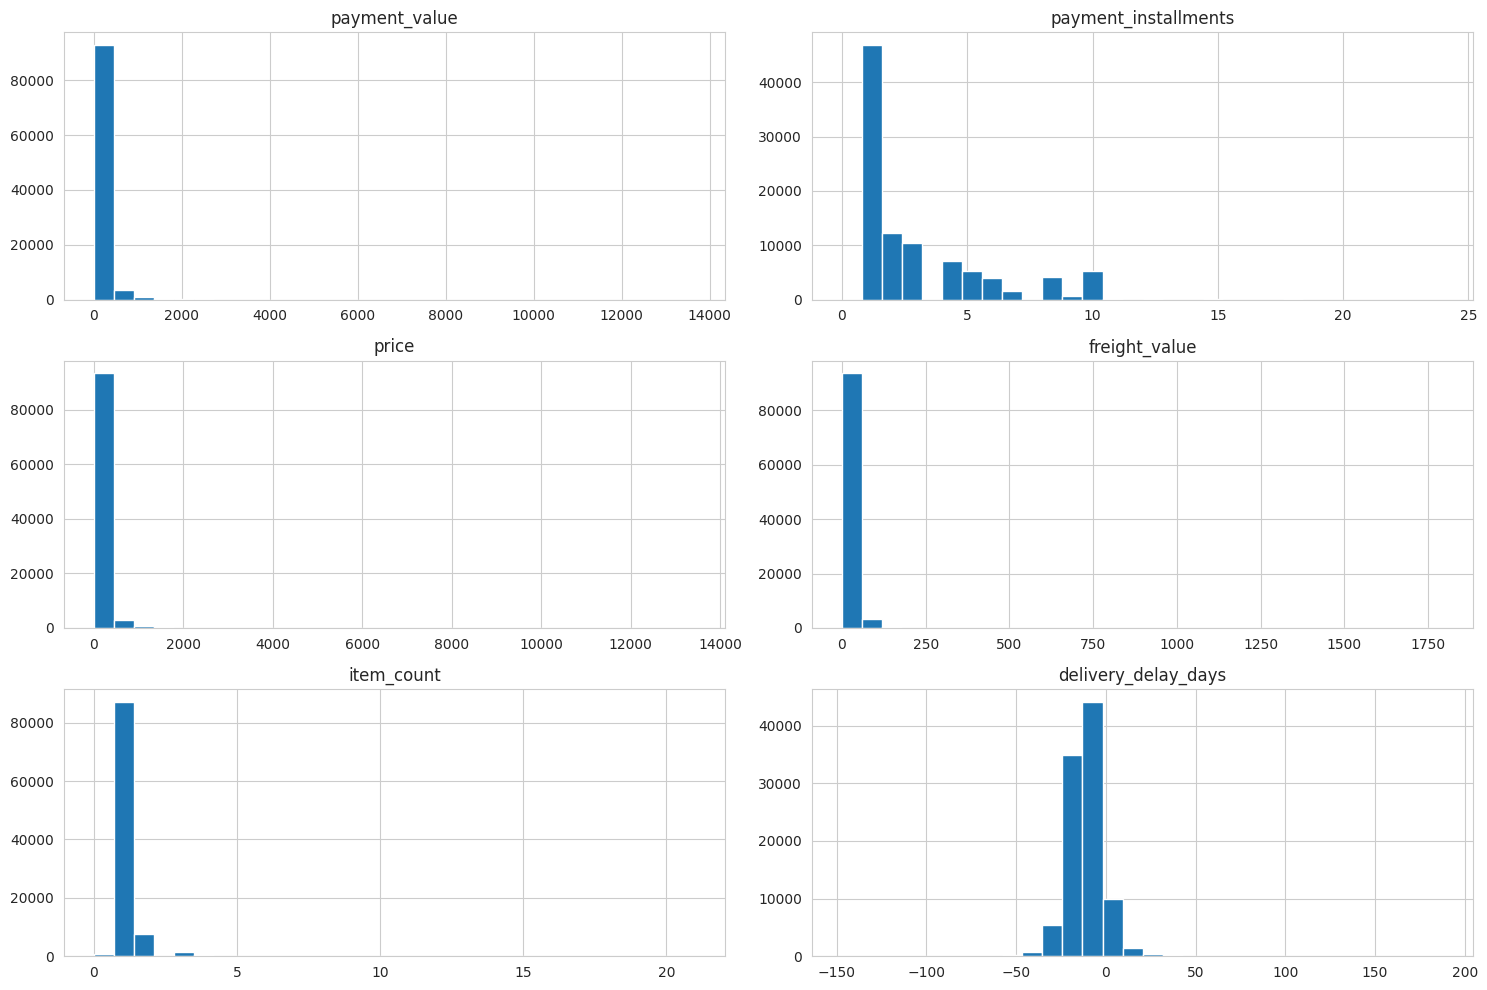

In [6]:
numerical_features = [
    'payment_value',
    'payment_installments',
    'price',
    'freight_value',
    'item_count',
    'delivery_delay_days'
]

final_df[numerical_features].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

# Relationship Between Delivery Delays and Risk

Delivery delays are expected to be a strong contributor to customer dissatisfaction. This analysis examines whether high-risk transactions exhibit longer delivery delays compared to low-risk transactions.

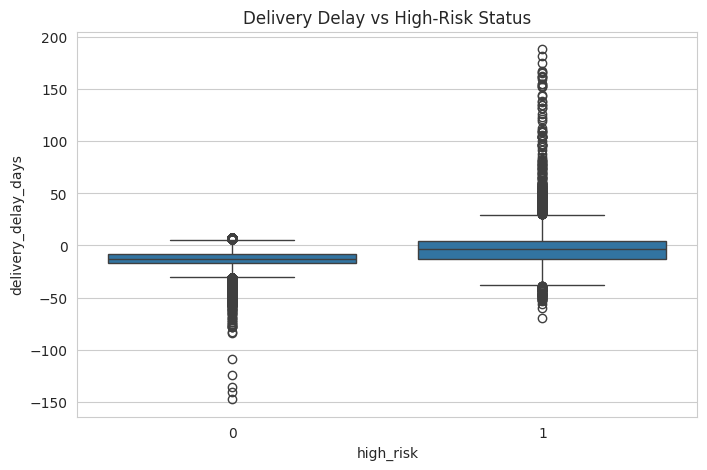

In [7]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='high_risk',
    y='delivery_delay_days',
    data=final_df
)

plt.title('Delivery Delay vs High-Risk Status')

plt.show()

### Observation

Orders classified as high-risk generally exhibit longer delivery delays than low-risk orders. This suggests that delivery performance is a strong indicator of customer dissatisfaction and may be an important predictive feature for the model.

# Payment Value and Transaction Risk

This analysis explores whether transaction value influences the likelihood of an order being classified as high-risk.

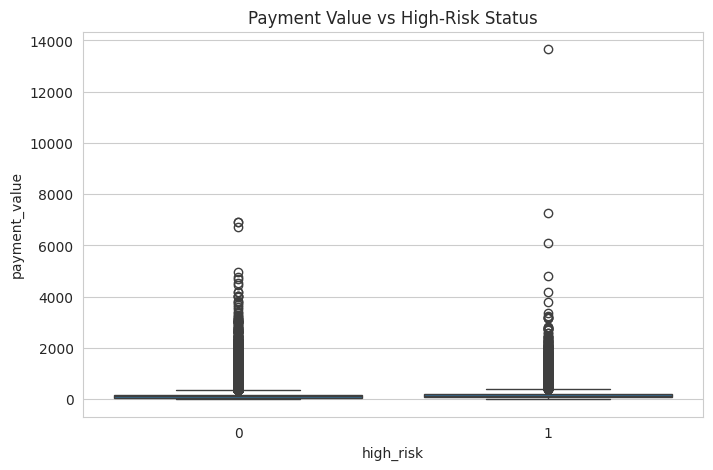

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='high_risk',
    y='payment_value',
    data=final_df
)

plt.title('Payment Value vs High-Risk Status')

plt.show()

# Freight Cost and Transaction Risk

Shipping costs may influence customer satisfaction and operational complexity. This analysis examines the relationship between freight value and transaction risk.

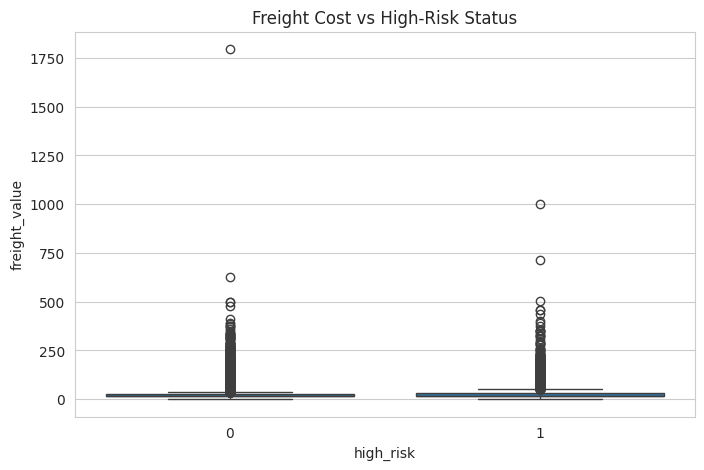

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='high_risk',
    y='freight_value',
    data=final_df
)

plt.title('Freight Cost vs High-Risk Status')

plt.show()

# Number of Items Purchased and Transaction Risk

Orders containing multiple items may be more complex from a logistics perspective and therefore may have different risk characteristics than single-item orders.

This analysis explores whether order size influences transaction risk.

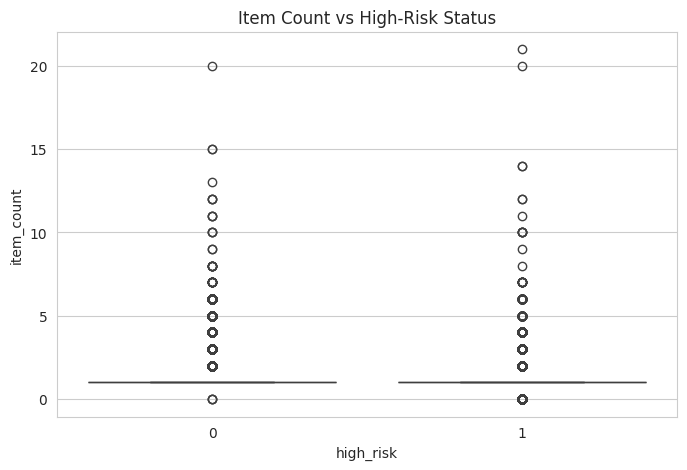

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='high_risk',
    y='item_count',
    data=final_df
)

plt.title(
    'Item Count vs High-Risk Status'
)

plt.show()

# Payment Instalments and Transaction Risk

Payment instalments may reflect purchasing behaviour and order complexity. This analysis investigates whether customers using a higher number of instalments exhibit different risk patterns.

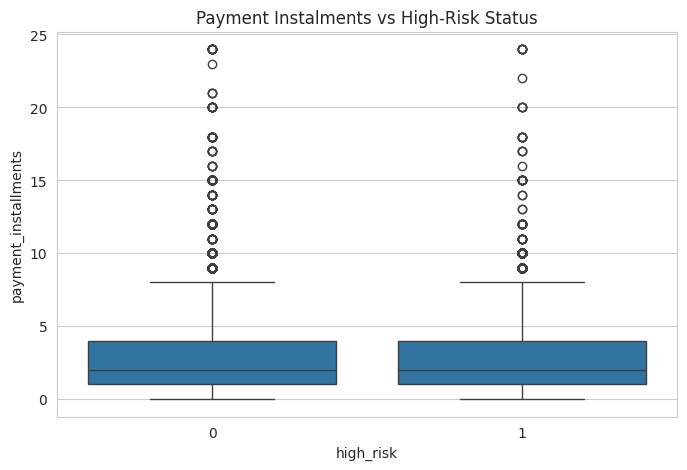

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='high_risk',
    y='payment_installments',
    data=final_df
)

plt.title(
    'Payment Instalments vs High-Risk Status'
)

plt.show()

# Correlation Analysis

A correlation matrix helps identify relationships between numerical features and highlights variables that may contribute most strongly to high-risk outcomes.

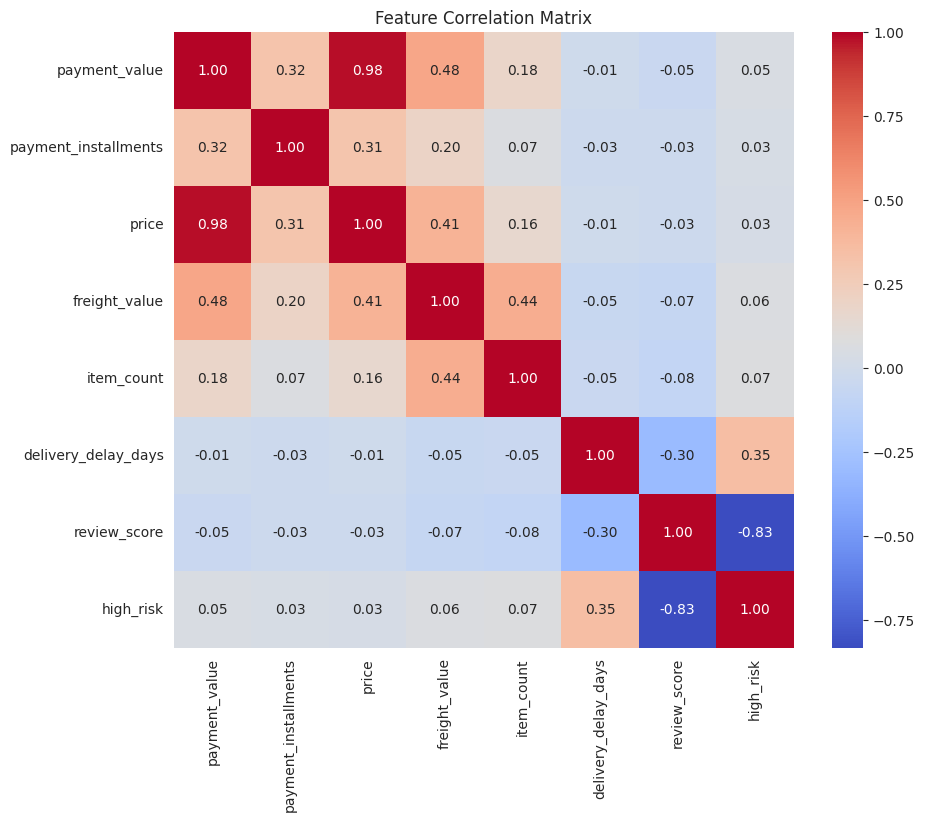

In [10]:
plt.figure(figsize=(10,8))

corr_matrix = final_df.select_dtypes(
    include=['int64','float64']
).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Matrix')

plt.show()

# Product Category Risk Analysis

Certain product categories may experience higher levels of customer dissatisfaction due to product quality issues, delivery complexity, or customer expectations.

This analysis identifies categories associated with higher rates of high-risk transactions.

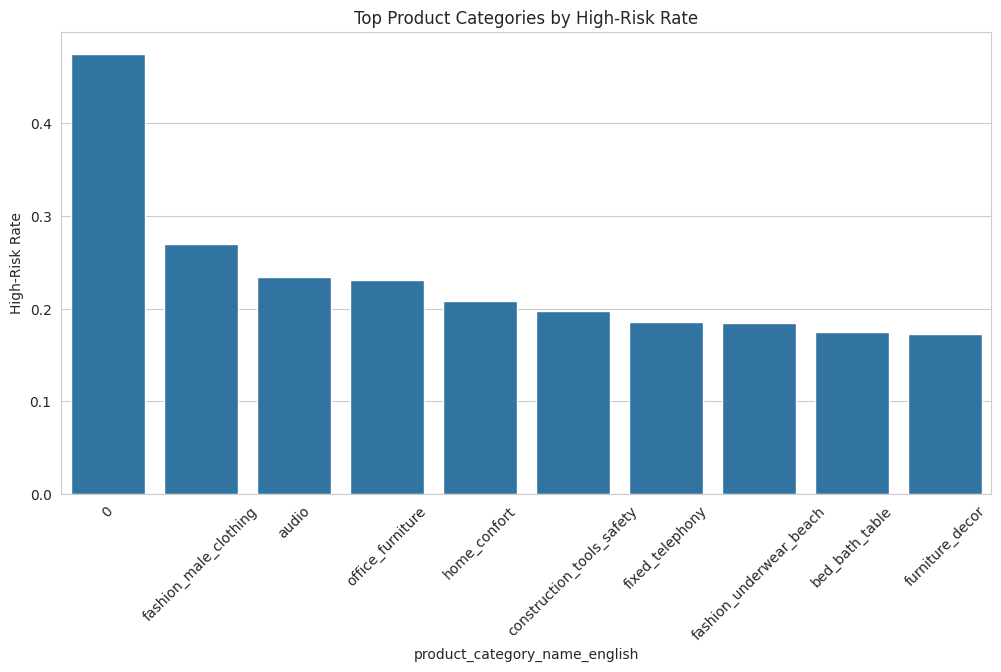

In [13]:
category_risk = (
    final_df
    .groupby('product_category_name_english')
    .agg(
        high_risk_rate=('high_risk','mean'),
        order_count=('high_risk','count')
    )
)

category_risk = (
    category_risk
    [category_risk['order_count'] >= 100]
    .sort_values(
        'high_risk_rate',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_risk.index,
    y=category_risk['high_risk_rate']
)

plt.xticks(rotation=45)

plt.title(
    'Top Product Categories by High-Risk Rate'
)

plt.ylabel('High-Risk Rate')

plt.show()

# Customer Review Score and Transaction Risk

Customer reviews are one of the strongest indicators of satisfaction. This analysis examines the relationship between review scores and the engineered high-risk target variable.

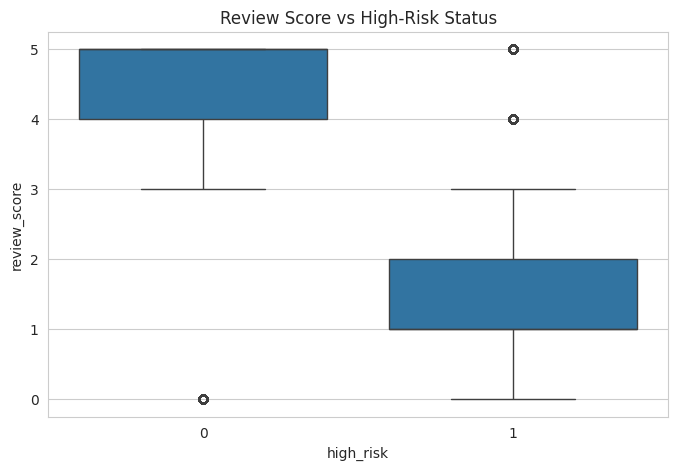

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='high_risk',
    y='review_score',
    data=final_df
)

plt.title(
    'Review Score vs High-Risk Status'
)

plt.show()

# Feature Correlation with Target

In [15]:
corr_with_target = (
    final_df
    .select_dtypes(include=['int64','float64'])
    .corr()['high_risk']
    .sort_values(ascending=False)
)

print(corr_with_target)

high_risk               1.000000
delivery_delay_days     0.353619
item_count              0.070317
freight_value           0.064425
payment_value           0.053151
payment_installments    0.033854
price                   0.031924
review_score           -0.833145
Name: high_risk, dtype: float64


# Features Most Correlated with High-Risk Transactions

To better understand which variables are most strongly associated with transaction risk, We visualise the correlation between each numerical feature and the target variable.

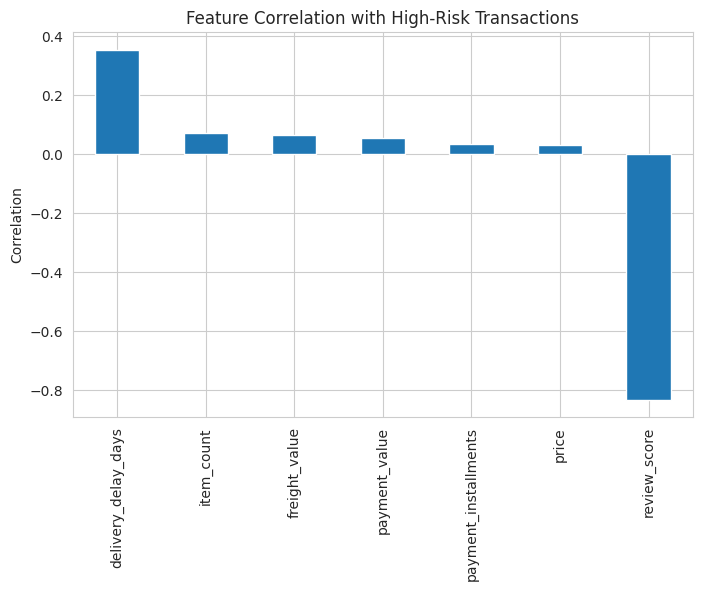

In [18]:
corr_with_target.drop('high_risk').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Feature Correlation with High-Risk Transactions'
)

plt.ylabel('Correlation')

plt.show()

# EDA Summary and Key Findings

The exploratory analysis provided several insights into the drivers of high-risk ecommerce transactions.

Key findings include:

- Approximately 16% of transactions were classified as high-risk, creating a moderately imbalanced but realistic classification problem.
- Delivery delays demonstrated one of the strongest relationships with transaction risk, indicating that fulfilment performance plays a critical role in customer satisfaction.
- Lower review scores were strongly associated with high-risk transactions, validating the business logic used during target engineering.
- Certain product categories exhibited substantially higher risk rates than others, suggesting that product characteristics may influence customer experience and operational complexity.
- Payment-related features, including transaction value and instalment usage, showed measurable variation across risk groups.
- Freight costs and order composition may contribute to transaction outcomes and warrant further investigation during model development.
- Correlation analysis identified several features with predictive potential, supporting their inclusion in machine learning models.

Overall, the EDA confirms that the engineered features capture meaningful operational and behavioural signals that can be leveraged to predict high-risk transactions before customer dissatisfaction occurs.